# Paso 1 — Matriz de tiempos y distancias

Primer bloque de la instancia base del sistema de barcos a demanda en Bergen (tesis NHH).

**Qué hace este notebook:**
1. Carga los 4 nodos de demanda (paradas reales) desde `config/instance.yaml`.
2. Calcula la distancia en línea recta sobre el agua (Haversine) entre cada par de nodos.
3. Aplica la **velocidad de diseño fija de la flota: 30 km/h** (`calibracion.velocidad_forzada_kmh`
   en `config/instance.yaml`) — es una decisión del equipo, no una velocidad calibrada de un
   ferry existente. El config deja documentado, como referencia histórica, el valor que se
   había calibrado antes con el tramo real Kleppestø–Bryggen (~23-24.6 km/h según el método).
4. Construye la matriz de tiempos de viaje (min) a partir de esa velocidad.
5. Guarda las matrices como CSV y genera las gráficas.
6. **Verificación visual**: dibuja las 6 líneas rectas (una por par de nodos) sobre el mapa
   real, con zoom cerrado en Bryggen, para revisar si alguna cruza tierra.

**Nota sobre Hegreneset:** no es una parada, es un punto de referencia sin demanda propia
(sección `waypoints` del config) — no entra en la matriz de tiempos.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point

sys.path.insert(0, str(Path.cwd().parent / "src"))
import geo

CONFIG_PATH = Path.cwd().parent / "config" / "instance.yaml"
OUTPUT_DIR = Path.cwd() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.width", 100)
plt.rcParams["figure.dpi"] = 110


## 1. Nodos de demanda

Las 4 paradas reales de la instancia base. Coordenadas WGS84 (grados decimales).


In [2]:
cfg = geo.cargar_instancia(CONFIG_PATH)
nodos_demanda_df = geo.nodos_a_dataframe(cfg["nodos_demanda"])
nodos_demanda_df[["nombre", "lat", "lon", "rol"]]


,nombre,lat,lon,rol
id,,,,
kleppesto,Kleppestø (Askøy),60.406500,5.227500,Punto de isla. Terminal actual de Askøybåten. ...
laksevag,Laksevåg (Gravdal),60.390886,5.259586,"Oeste, en Gravdal, cruzando el Puddefjorden. C..."
bryggen,Bryggen / Sentrum,60.395100,5.322300,Hub central (Strandkaiterminalen). Máxima dema...
sandviken,Sandviken (BSI Padling),60.421149,5.300502,"Norte, en BSI Padling (club de piragüismo), ca..."


## 2. Distancias Haversine

Distancia en línea recta sobre el agua entre cada par de nodos, en kilómetros.
Es una aproximación: en la v1 se acepta que algunas rectas puedan bordear tierra
(ver `docs/parametros_instancia_base_bergen.md`); se refina después con datos AIS.


In [3]:
dist_km = geo.matriz_distancias(nodos_demanda_df)
dist_km.round(2)


,kleppesto,laksevag,bryggen,sandviken
kleppesto,0.00,2.47,5.36,4.33
laksevag,2.47,0.00,3.48,4.05
bryggen,5.36,3.48,0.00,3.13
sandviken,4.33,4.05,3.13,0.00


## 3. Velocidad de diseño (fija)

En vez de calibrar la velocidad con un tramo real, la flota de barcos a demanda usa una
**velocidad de diseño fija: 30 km/h** (~16.2 nudos), definida en
`config/instance.yaml` (`calibracion.velocidad_forzada_kmh`). Es una decisión de diseño del
equipo, no una velocidad heredada de un ferry existente.


In [4]:
cal = cfg["calibracion"]
velocidad_kmh = geo.calibrar_velocidad_kmh(
    nodos_demanda_df,
    desde=cal["referencia_desde"],
    hasta=cal["referencia_hasta"],
    tiempo_referencia_min=cal["tiempo_referencia_min"],
    velocidad_forzada_kmh=cal.get("velocidad_forzada_kmh"),
)
print(f"Velocidad de diseño usada: {velocidad_kmh:.2f} km/h ({velocidad_kmh/1.852:.1f} nudos)")
if cal.get("velocidad_forzada_kmh") is not None:
    print("(fijada en config/instance.yaml -> calibracion.velocidad_forzada_kmh, no calibrada de un tramo real)")


Velocidad de diseño usada: 30.00 km/h (16.2 nudos)
(fijada en config/instance.yaml -> calibracion.velocidad_forzada_kmh, no calibrada de un tramo real)


## 4. Matriz de tiempos de viaje

Con la velocidad de diseño (30 km/h), convertimos la matriz de distancias a minutos.


In [5]:
tiempos_min = geo.matriz_tiempos(dist_km, velocidad_kmh)
tiempos_min.round(1)


,kleppesto,laksevag,bryggen,sandviken
kleppesto,0.0,4.9,10.7,8.7
laksevag,4.9,0.0,7.0,8.1
bryggen,10.7,7.0,0.0,6.3
sandviken,8.7,8.1,6.3,0.0


In [6]:
# Con velocidad fija (no calibrada), el tramo Kleppestø-Bryggen ya NO tiene por qué dar
# exactamente 14 min -- ese valor solo aplicaba cuando se calibraba contra el dato real.
print("Kleppestø-Bryggen a 30 km/h:", round(tiempos_min.loc["kleppesto", "bryggen"], 2), "min",
      "(el dato real del ferry 490 es 14 min; la diferencia es porque ya no calibramos contra él)")


Kleppestø-Bryggen a 30 km/h: 10.72 min (el dato real del ferry 490 es 14 min; la diferencia es porque ya no calibramos contra él)


## 5. Guardar matrices

Se guardan como CSV en `output/` para que otros pasos (demanda, simulación, despacho)
las puedan leer sin recalcular.


In [7]:
dist_km.to_csv(OUTPUT_DIR / "matriz_distancias_km.csv")
tiempos_min.to_csv(OUTPUT_DIR / "matriz_tiempos_min.csv")

with open(OUTPUT_DIR / "velocidad_calibrada_kmh.txt", "w", encoding="utf-8") as f:
    f.write(f"{velocidad_kmh:.6f}\n")

print("Guardado en:", OUTPUT_DIR)
list(OUTPUT_DIR.iterdir())


Guardado en: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\bergen-boats\01_tiempos_distancias\output


[WindowsPath('C:/Users/hfons/Andes/OneDrive - Universidad de los Andes/NHH/bergen-boats/01_tiempos_distancias/output/heatmap_tiempos.png'),
 WindowsPath('C:/Users/hfons/Andes/OneDrive - Universidad de los Andes/NHH/bergen-boats/01_tiempos_distancias/output/mapa_lineas_rectas.png'),
 WindowsPath('C:/Users/hfons/Andes/OneDrive - Universidad de los Andes/NHH/bergen-boats/01_tiempos_distancias/output/mapa_lineas_rectas_detalle.png'),
 WindowsPath('C:/Users/hfons/Andes/OneDrive - Universidad de los Andes/NHH/bergen-boats/01_tiempos_distancias/output/mapa_nodos_bergen.png'),
 WindowsPath('C:/Users/hfons/Andes/OneDrive - Universidad de los Andes/NHH/bergen-boats/01_tiempos_distancias/output/mapa_zoom_bryggen.png'),
 WindowsPath('C:/Users/hfons/Andes/OneDrive - Universidad de los Andes/NHH/bergen-boats/01_tiempos_distancias/output/matriz_distancias_km.csv'),
 WindowsPath('C:/Users/hfons/Andes/OneDrive - Universidad de los Andes/NHH/bergen-boats/01_tiempos_distancias/output/matriz_distancias_km

## 6. Mapa de los nodos sobre Bergen

Los 4 nodos de demanda se muestran como marcadores llenos; Hegreneset se muestra aparte,
en gris y con un marcador distinto, como *waypoint* de referencia — para dejar visualmente
claro que no es una parada de demanda.


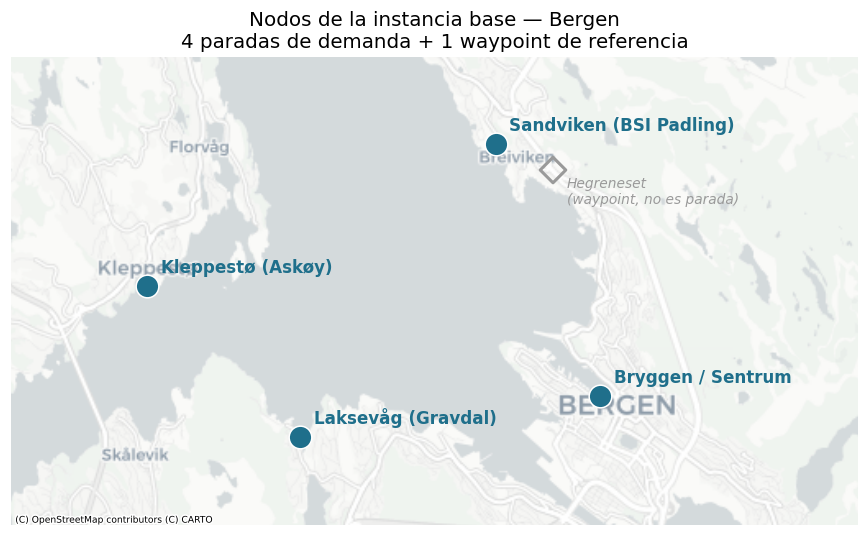

In [8]:
waypoints_df = geo.nodos_a_dataframe(cfg.get("waypoints", []))

gdf_demanda = gpd.GeoDataFrame(
    nodos_demanda_df,
    geometry=[Point(lon, lat) for lat, lon in zip(nodos_demanda_df["lat"], nodos_demanda_df["lon"])],
    crs="EPSG:4326",
).to_crs(epsg=3857)

gdf_waypoints = gpd.GeoDataFrame(
    waypoints_df,
    geometry=[Point(lon, lat) for lat, lon in zip(waypoints_df["lat"], waypoints_df["lon"])],
    crs="EPSG:4326",
).to_crs(epsg=3857)

COLOR_DEMANDA = "#1f6f8b"   # azul-verdoso, nodos de demanda
COLOR_WAYPOINT = "#9a9a9a"  # gris, waypoint (no es parada)

fig, ax = plt.subplots(figsize=(8, 8))

gdf_demanda.plot(ax=ax, color=COLOR_DEMANDA, edgecolor="white", markersize=220, zorder=3)
gdf_waypoints.plot(
    ax=ax, color="none", edgecolor=COLOR_WAYPOINT, linewidth=2,
    marker="D", markersize=140, zorder=3,
)

for nid, row in gdf_demanda.iterrows():
    ax.annotate(
        nodos_demanda_df.loc[nid, "nombre"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(9, 9), textcoords="offset points",
        fontsize=11, fontweight="bold", color=COLOR_DEMANDA,
    )

for nid, row in gdf_waypoints.iterrows():
    ax.annotate(
        waypoints_df.loc[nid, "nombre"] + "\n(waypoint, no es parada)",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(9, -22), textcoords="offset points",
        fontsize=9, style="italic", color=COLOR_WAYPOINT,
    )

# margen alrededor de los puntos para que el mapa respire
xmin, ymin, xmax, ymax = pd.concat([gdf_demanda, gdf_waypoints]).total_bounds
mx, my = (xmax - xmin) * 0.30, (ymax - ymin) * 0.30
ax.set_xlim(xmin - mx, xmax + mx * 1.9)
ax.set_ylim(ymin - my, ymax + my)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution_size=6)

ax.set_axis_off()
ax.set_title("Nodos de la instancia base — Bergen\n4 paradas de demanda + 1 waypoint de referencia", fontsize=13)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapa_nodos_bergen.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Heatmap de la matriz de tiempos

Vista rápida de qué tan conectados están los nodos entre sí. Bryggen es el hub central:
sus tiempos a los demás nodos son consistentemente bajos.


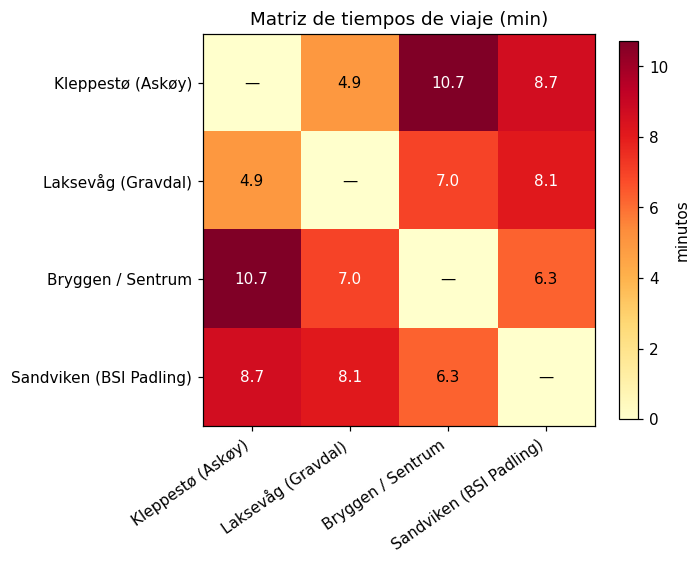

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

etiquetas = nodos_demanda_df["nombre"].tolist()
im = ax.imshow(tiempos_min.values, cmap="YlOrRd", vmin=0)

ax.set_xticks(range(len(etiquetas)))
ax.set_yticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=35, ha="right")
ax.set_yticklabels(etiquetas)

for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        valor = tiempos_min.values[i, j]
        texto = "—" if i == j else f"{valor:.1f}"
        color = "white" if valor > tiempos_min.values.max() * 0.6 else "black"
        ax.text(j, i, texto, ha="center", va="center", color=color, fontsize=10)

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("minutos")

ax.set_title("Matriz de tiempos de viaje (min)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmap_tiempos.png", dpi=200, bbox_inches="tight")
plt.show()


## 8. Referencia: matriz incluyendo Hegreneset como waypoint

Solo para dejar documentado, por si en un paso posterior hace falta la geometría exacta
de un tramo que pase cerca de Hegreneset (p.ej. para bordear la costa). **No se usa** en
la matriz de demanda ni en la política de despacho — de ahí que se guarde en un CSV aparte.


In [10]:
_, dist_km_ref, tiempos_min_ref, _ = geo.construir_matrices(CONFIG_PATH, incluir_waypoints=True)

dist_km_ref.to_csv(OUTPUT_DIR / "matriz_distancias_km_con_waypoints_REFERENCIA.csv")
tiempos_min_ref.to_csv(OUTPUT_DIR / "matriz_tiempos_min_con_waypoints_REFERENCIA.csv")

tiempos_min_ref.round(1)


,kleppesto,laksevag,bryggen,sandviken,hegreneset
kleppesto,0.0,4.9,10.7,8.7,9.7
laksevag,4.9,0.0,7.0,8.1,8.5
bryggen,10.7,7.0,0.0,6.3,5.3
sandviken,8.7,8.1,6.3,0.0,1.4
hegreneset,9.7,8.5,5.3,1.4,0.0


## 9. Verificación visual — ¿alguna línea recta cruza tierra?

Haversine calcula la distancia "como vuela el pájaro": una línea recta entre dos
coordenadas, sin saber si esa línea pasa sobre agua o sobre tierra. Para 3 de los
4 nodos esto es razonablemente seguro (están sobre el mismo fiordo abierto), pero
**Bryggen es el caso a revisar de cerca**: está metido en el fondo de la bahía de
Vågen, y justo al oeste queda la **península de Nordnes**, una lengua de tierra
que separa Vågen/el puerto central de Puddefjorden (donde está Laksevåg). Una
línea recta Laksevåg↔Bryggen o Sandviken↔Bryggen podría perfectamente cruzar esa
península en vez de bordearla por agua.

Abajo se dibujan las 6 líneas rectas (una por cada par de nodos) sobre el mapa
real, primero una vista general y después un zoom cerrado sobre Bryggen.


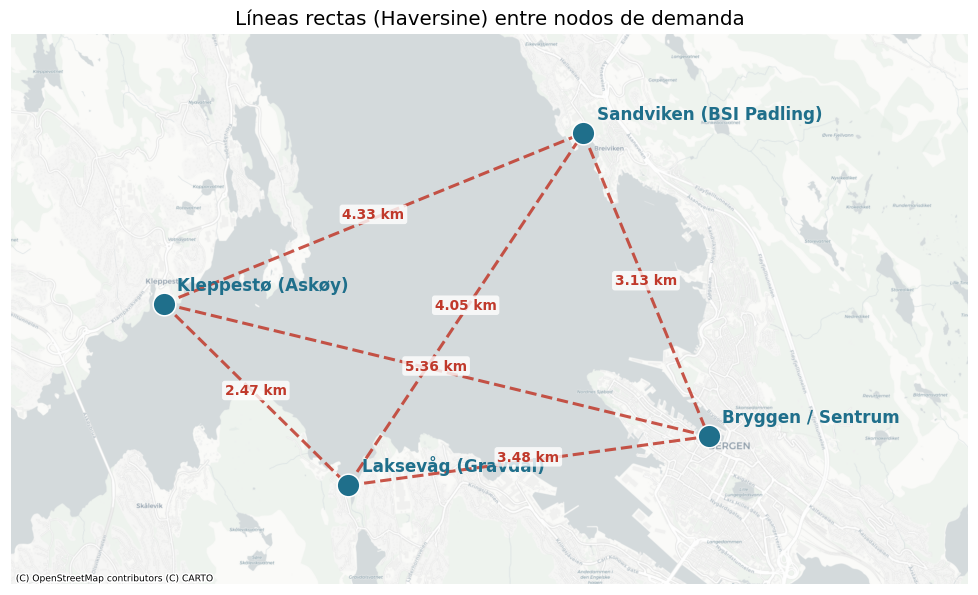

In [11]:
import itertools
from shapely.geometry import LineString

pares = list(itertools.combinations(nodos_demanda_df.index.tolist(), 2))
lineas = []
for a, b in pares:
    pa, pb = gdf_demanda.loc[a, "geometry"], gdf_demanda.loc[b, "geometry"]
    lineas.append({
        "desde": a, "hasta": b,
        "desde_nombre": nodos_demanda_df.loc[a, "nombre"],
        "hasta_nombre": nodos_demanda_df.loc[b, "nombre"],
        "distancia_km": dist_km.loc[a, b],
        "geometry": LineString([pa, pb]),
    })
gdf_lineas = gpd.GeoDataFrame(lineas, crs=gdf_demanda.crs)

fig, ax = plt.subplots(figsize=(9, 9))

gdf_lineas.plot(ax=ax, color="#c0392b", linewidth=2, linestyle="--", alpha=0.85, zorder=2)
gdf_demanda.plot(ax=ax, color=COLOR_DEMANDA, edgecolor="white", markersize=220, zorder=3)

for nid, row in gdf_demanda.iterrows():
    ax.annotate(
        nodos_demanda_df.loc[nid, "nombre"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(9, 9), textcoords="offset points",
        fontsize=11, fontweight="bold", color=COLOR_DEMANDA, zorder=4,
    )

for _, row in gdf_lineas.iterrows():
    mid = row.geometry.interpolate(0.5, normalized=True)
    ax.annotate(
        f"{row.distancia_km:.2f} km",
        xy=(mid.x, mid.y), ha="center", fontsize=9, fontweight="bold", color="#c0392b",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8), zorder=5,
    )

xmin, ymin, xmax, ymax = gdf_demanda.total_bounds
mx, my = (xmax - xmin) * 0.28, (ymax - ymin) * 0.28
ax.set_xlim(xmin - mx, xmax + mx * 1.7)
ax.set_ylim(ymin - my, ymax + my)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution_size=6, zoom=14)
ax.set_axis_off()
ax.set_title("Líneas rectas (Haversine) entre nodos de demanda", fontsize=13)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapa_lineas_rectas.png", dpi=200, bbox_inches="tight")
plt.show()


### Zoom sobre Bryggen y la península de Nordnes

Vista cerrada (radio ≈ 2 km) centrada en Bryggen, con mapa de calles (más detalle
de costa/edificios que el mapa gris anterior) para juzgar mejor si las líneas
cruzan tierra.


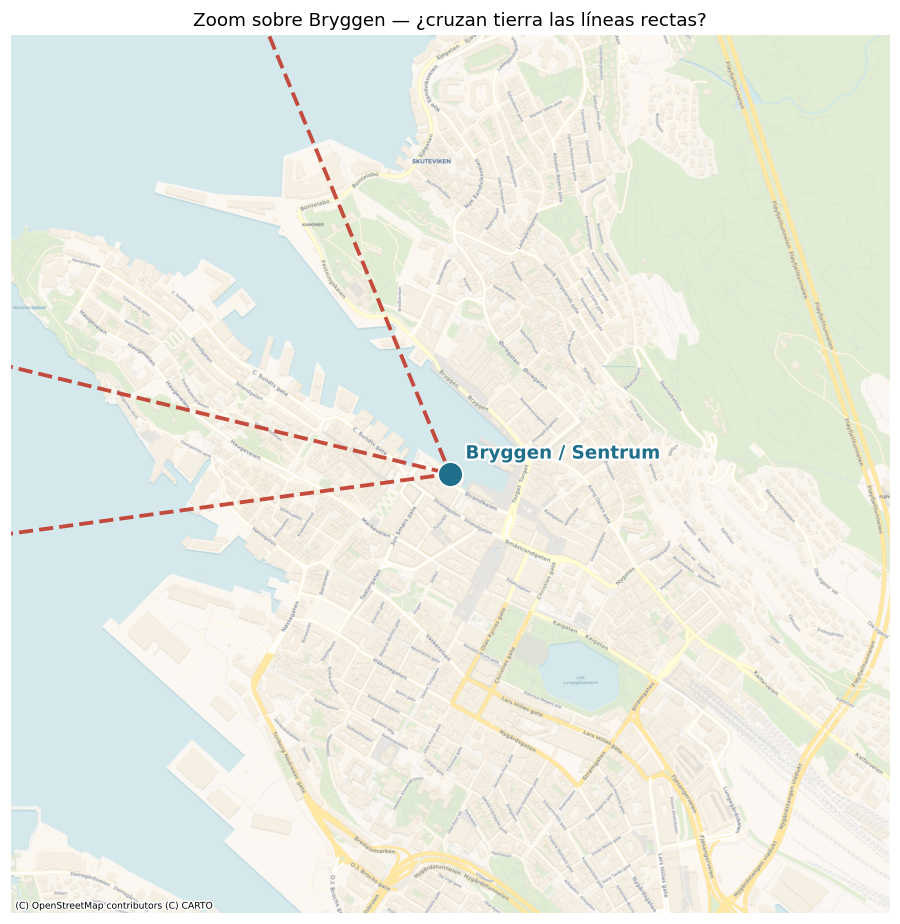

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 8.5))

gdf_lineas.plot(ax=ax, color="#c0392b", linewidth=2.5, linestyle="--", alpha=0.9, zorder=2)
gdf_demanda.plot(ax=ax, color=COLOR_DEMANDA, edgecolor="white", markersize=260, zorder=3)

for nid, row in gdf_demanda.iterrows():
    ax.annotate(
        nodos_demanda_df.loc[nid, "nombre"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(10, 10), textcoords="offset points",
        fontsize=12, fontweight="bold", color=COLOR_DEMANDA, zorder=4,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

bx = gdf_demanda.loc["bryggen", "geometry"]
radio_m = 2300  # metros (EPSG:3857 ~ metros)
ax.set_xlim(bx.x - radio_m, bx.x + radio_m)
ax.set_ylim(bx.y - radio_m, bx.y + radio_m)

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, attribution_size=6, zoom=16)
ax.set_axis_off()
ax.set_title("Zoom sobre Bryggen — ¿cruzan tierra las líneas rectas?", fontsize=12)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapa_zoom_bryggen.png", dpi=200, bbox_inches="tight")
plt.show()


### Vista intermedia — las 6 líneas con calles de fondo

Radio más amplio (~4.5 km desde el centro de la instancia) pero manteniendo el mapa
de calles, para juzgar de un vistazo las 6 conexiones a la vez.


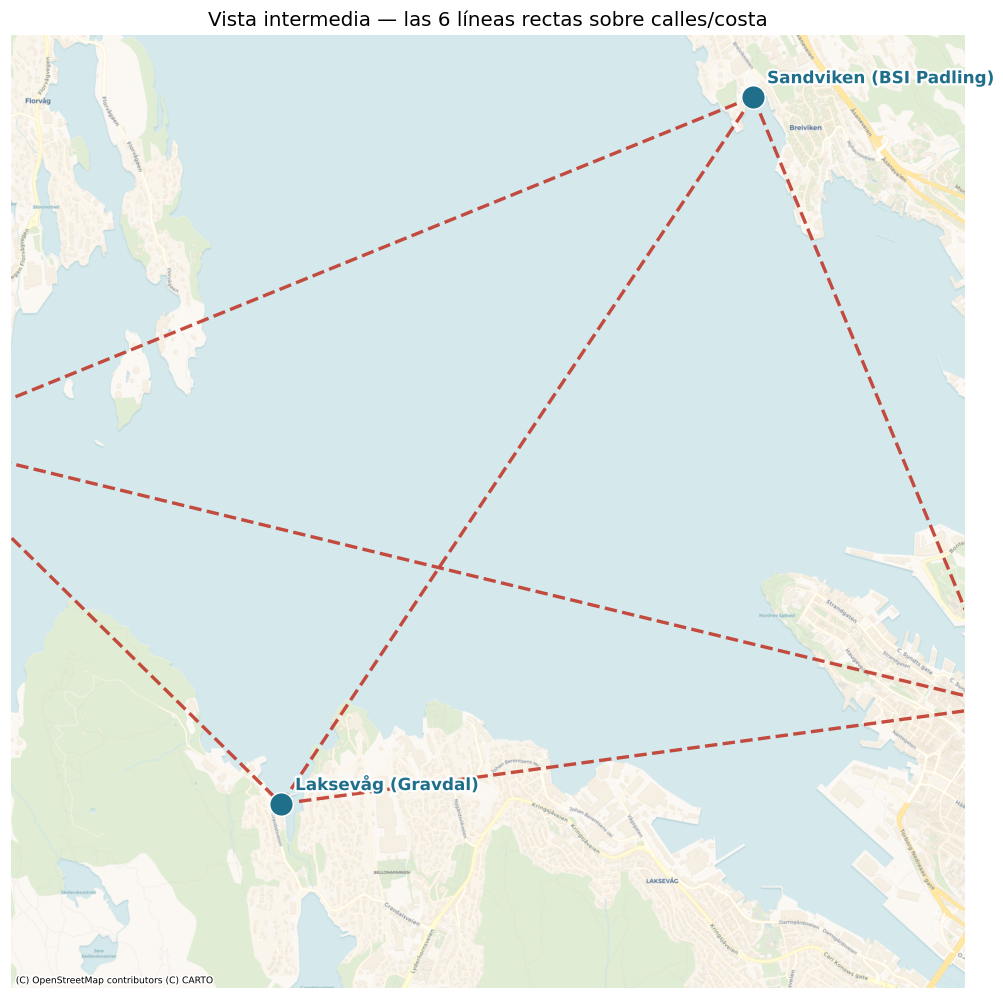

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 9.5))

gdf_lineas.plot(ax=ax, color="#c0392b", linewidth=2.2, linestyle="--", alpha=0.9, zorder=2)
gdf_demanda.plot(ax=ax, color=COLOR_DEMANDA, edgecolor="white", markersize=240, zorder=3)

for nid, row in gdf_demanda.iterrows():
    ax.annotate(
        nodos_demanda_df.loc[nid, "nombre"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(9, 9), textcoords="offset points",
        fontsize=11, fontweight="bold", color=COLOR_DEMANDA, zorder=4,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")],
    )

cx_, cy_ = gdf_demanda.union_all().centroid.x, gdf_demanda.union_all().centroid.y
radio_m = 4600
ax.set_xlim(cx_ - radio_m, cx_ + radio_m)
ax.set_ylim(cy_ - radio_m, cy_ + radio_m)

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, attribution_size=6, zoom=15)
ax.set_axis_off()
ax.set_title("Vista intermedia — las 6 líneas rectas sobre calles/costa", fontsize=13)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mapa_lineas_rectas_detalle.png", dpi=200, bbox_inches="tight")
plt.show()


### Qué se ve en los mapas (conclusión de la inspección visual)

Revisando las 6 líneas sobre calle/costa real (ver `output/mapa_lineas_rectas.png`,
`output/mapa_lineas_rectas_detalle.png` y `output/mapa_zoom_bryggen.png`):

- Las líneas que tocan **Bryggen** son las que más riesgo tienen de cruzar tierra: Bryggen
  está metida en la bahía de Vågen, junto a la península de Nordnes, así que cualquier recta
  hacia el oeste (Laksevåg, Kleppestø) o hacia el norte (Sandviken) tiene que "atravesar" esa
  geografía en vez de bordearla.
- Las conexiones que quedan sobre fiordo abierto, sin tierra angosta de por medio, no
  deberían tener este problema.
- Revisa las imágenes con las coordenadas actuales de `config/instance.yaml` antes de confiar
  en la matriz de este notebook — los números específicos cambian cada vez que se ajustan
  las coordenadas de los nodos, así que no se repiten aquí para no quedar desactualizados.

**Implicación:** como Bryggen concentra las 3 conexiones fuertes del modelo (garantía dura
de 15 min), esto es relevante: la distancia Haversine ahí probablemente **subestima** la
distancia real que navegaría un barco.

Esto se deja documentado como limitación conocida (ver `docs/parametros_instancia_base_bergen.md`
en la raíz del proyecto de tesis) — la corrección real está en `../02_ruteo_navegable/`, que
rutea sobre una malla de agua en vez de usar líneas rectas.


## Resumen

- Velocidad de diseño usada: **fija, definida en `config/instance.yaml`** (no calibrada de un tramo real).
- Matriz de tiempos de la instancia base (4 nodos de demanda) calculada en línea recta (Haversine).
- Verificación visual (sección 9): revisar `output/mapa_lineas_rectas.png` y `output/mapa_zoom_bryggen.png` —
  las líneas rectas que tocan Bryggen probablemente cruzan tierra (ver conclusión arriba).
- Outputs guardados en `output/`: matrices de distancia/tiempo, velocidad usada, mapas y heatmap.
- **Siguiente paso:** `../02_ruteo_navegable/` — corrige el problema de arriba ruteando sobre
  una malla de agua real en vez de líneas rectas. Esa es la matriz que deben usar los pasos
  posteriores (`03_demanda/` en adelante), no la de aquí.
